SVM Accuracy: 0.9
[[202   0   1   0   0   1   1   0   2   0]
 [  0 210   2   0   0   1   0   1   2   0]
 [  4   3 169   8   1   3   4   1   9   2]
 [  0   1   5 165   0   9   2   3   5   2]
 [  0   0   3   0 191   2   4   1   1   9]
 [  4   3   3  11   1 148   2   0   3   1]
 [  1   0   2   0   0   5 210   0   1   1]
 [  0   1   2   2   3   1   0 202   0   5]
 [  0   2   1  11   2   3   0   3 139   5]
 [  2   0   2   5   2   1   1  13   2 164]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       207
           1       0.95      0.97      0.96       216
           2       0.89      0.83      0.86       204
           3       0.82      0.86      0.84       192
           4       0.95      0.91      0.93       211
           5       0.85      0.84      0.85       176
           6       0.94      0.95      0.95       220
           7       0.90      0.94      0.92       216
           8       0.85      0.84      0.84       166
          

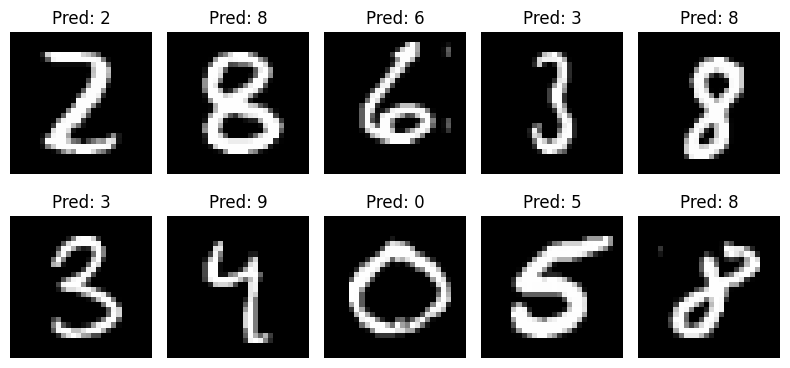

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mnist = fetch_openml('mnist_784', version=1, as_frame=True)
X = mnist.data
y = mnist.target.astype(int)

X = X[:10000]
y = y[:10000]

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title("Pred: " + str(y_pred_knn.iloc[i] if hasattr(y_pred_knn, 'iloc') else y_pred_knn[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()